In [81]:
import HTSeq
import numpy as np
np.random.seed(1337)
import pysam
import os
import shutil

from price2.reference_annotation import ReferenceAnnotation

from price2.genomic_region import GenomicRegion
from price2.cleavage_model import CleavageModel, select_and_scale
from price2.ribo_seq_run import RiboSeqRun

import pandas as pd

import numba as nb
nb.set_num_threads(32)

In [82]:
# should contain:
#   upstream cleavage model
#   downstream cleavage model
#   reference annotation
#   orf annotation
directory = '/projects/viro/maidhof/price2/orf_deconvolution_development/simulated_data'
fasta_path = f'{directory}/generated_data/orf_deconvolution.fasta'
bam_dir = f'{directory}/generated_data/bams'
gtf_path = f'{directory}/input_data/orf_deconvolution.gtf'
orf_gtf = f'{directory}/input_data/orf_deconvolution_ORFs.gtf'
workingdir = f'{directory}/workingdir'


# test if directory exists
if os.path.exists(f'{directory}/generated_data'):
    shutil.rmtree(f'{directory}/generated_data')
os.mkdir(f'{directory}/generated_data')
os.mkdir(bam_dir)

In [83]:
pl = np.loadtxt(f'{directory}/input_data/upstream_cleavage_model')
pl = pl / pl.sum()
pr = np.loadtxt(f'{directory}/input_data/downstream_cleavage_model')
pr = pr / pr.sum()
u = .2
cm = CleavageModel(pl, pr, u)

r = 1 # regularization parameter
pr_reg = select_and_scale(pr, r)
pl_reg = select_and_scale(pl, r)

cm_regularized = CleavageModel(pl_reg, pr_reg, u)

In [84]:
ra = ReferenceAnnotation(gtf_path)
ra.transcripts

{'transcript1': <price2.genomic_features.Transcript at 0x7fa4b861c7c0>,
 'transcript2': <price2.genomic_features.Transcript at 0x7fa7f87f0eb0>,
 'transcript3': <price2.genomic_features.Transcript at 0x7fa4bb5a1120>,
 'transcript4': <price2.genomic_features.Transcript at 0x7fa4bb5a3e50>,
 'transcript5': <price2.genomic_features.Transcript at 0x7fa4bb9e5db0>,
 'transcript6': <price2.genomic_features.Transcript at 0x7fa4ba83c3d0>,
 'transcript7': <price2.genomic_features.Transcript at 0x7fa4bb932ce0>}

In [85]:
seqs = {}

fasta_1 = 'N'*70000

final_orfs = {}
for orf in HTSeq.GFF_Reader(orf_gtf):
    if orf.iv.chrom == 'chr1':
        if orf.attr['ID'] not in final_orfs:
            if orf.iv.strand == '+':
                fasta_1 = fasta_1[:orf.iv.start] + 'ATG' + fasta_1[orf.iv.start+3:]
            else:
                fasta_1 = fasta_1[:orf.iv.end-3] + 'CAT' + fasta_1[orf.iv.end:]
        final_orfs[orf.attr['ID']] = orf

for orf in final_orfs.values():
    if orf.iv.strand == '+':
        fasta_1 = fasta_1[:orf.iv.end-3] + 'TAG' + fasta_1[orf.iv.end:]
    else:
        fasta_1 = fasta_1[:orf.iv.start-3] + 'CTA' + fasta_1[orf.iv.start:]

seqs['chr1'] = HTSeq.Sequence(fasta_1.encode('ascii'), 'chr1')

fasta_2 = 'N'*100000

final_orfs = {}
for orf in HTSeq.GFF_Reader(orf_gtf):
    if orf.iv.chrom == 'chr2':
        if orf.attr['ID'] not in final_orfs:
            if orf.iv.strand == '+':
                fasta_2 = fasta_2[:orf.iv.start] + 'ATG' + fasta_2[orf.iv.start+3:]
            else:
                fasta_2 = fasta_2[:orf.iv.end-3] + 'CAT' + fasta_2[orf.iv.end:]
        final_orfs[orf.attr['ID']] = orf

for orf in final_orfs.values():
    if orf.iv.strand == '+':
        fasta_2 = fasta_2[:orf.iv.end-3] + 'TAG' + fasta_2[orf.iv.end:]
    else:
        fasta_2 = fasta_2[:orf.iv.start] + 'CTA' + fasta_2[orf.iv.start+3:]

seqs['chr2'] = HTSeq.Sequence(fasta_2.encode('ascii'), 'chr2')


with open(f'{directory}/generated_data/orf_deconvolution.fasta', 'w') as f:
    for seq in seqs.values():
        seq.write_to_fasta_file(f)

In [86]:
class ReadGeneratingRegionGenerator:
    id: str
    type: str
    genomic_region: GenomicRegion
    activity_mean: float
    activity_std: float
    length: int

    def __init__(self, activity_mean: float, activity_std: float, genomic_region, id: str, type: str):
        self.type = type
        self.id = id
        self.genomic_region = genomic_region
        self.activity_mean = activity_mean
        self.activity_std = activity_std

read_generating_regions = {}

for orf in HTSeq.GFF_Reader(orf_gtf):
    if not orf.attr['ID'] in read_generating_regions:
        read_generating_regions[orf.attr['ID']] = ReadGeneratingRegionGenerator(
            int(orf.attr['activity_mean']),
            int(orf.attr['activity_std']),
            GenomicRegion([], orf.iv.chrom, orf.iv.strand),
            id = orf.attr['ID'],
            type = 'ORF'
            )

    read_generating_regions[orf.attr['ID']].genomic_region.add_interval(orf.iv)

for region in HTSeq.GFF_Reader(gtf_path):
    if region.type == 'transcript':
        if not region.attr['transcript_id'] in read_generating_regions:
            read_generating_regions[region.attr['transcript_id']] = ReadGeneratingRegionGenerator(
                int(region.attr['activity_mean']),
                int(region.attr['activity_std']),
                GenomicRegion([], region.iv.chrom, region.iv.strand),
                id = region.attr['transcript_id'],
                type = 'NOISE'
                )
    elif region.type == 'exon':
        read_generating_regions[region.attr['transcript_id']].genomic_region.add_interval(region.iv)



In [87]:
class RunGenerator:
    def __init__(self, id, num_reads, read_generating_regions, cm, random_reads=0):
        self.id = id
        self.num_reads = num_reads
        self.random_reads = random_reads
        self.cleavage_model = cm
        self.read_generating_regions = read_generating_regions
        #self.region_activities = {k: np.random.normal(rg.activity_mean, rg.activity_std) for k, rg in read_generating_regions.items()}
        self.region_activities = {k: rg.activity_mean for k, rg in read_generating_regions.items()}
        self.region_activities = {k: max(0, v) for k, v in self.region_activities.items()}
        for rgr in read_generating_regions.values():
            rgr.length = len(rgr.genomic_region)
        likelihoods = {k: rg.length * self.region_activities[k] for k, rg in read_generating_regions.items()}
        s = sum(likelihoods.values())
        self.probabilities = {k: l/s for k, l in likelihoods.items()}


    def generate_read(self):
        region = np.random.choice(list(self.probabilities.keys()), p=list(self.probabilities.values()))
        region = self.read_generating_regions[region]
        l,r,u = cm.rvs()
        l,r,u = l[0],r[0],u[0]
        if u:
            u_observed = np.random.choice([True, False], p=[.75, .25])
        else:
            u_observed = False
        
        if region.type == 'ORF':
            p_site_position_in_orf = np.random.randint(0, region.length//3)*3
        elif region.type == 'NOISE':
            p_site_position_in_orf = np.random.randint(0, region.length)
        matching_interval_on_orf = (p_site_position_in_orf - l - int(u) + int(u_observed), p_site_position_in_orf + r + 3)
        matching_interval_on_genome = region.genomic_region.map(matching_interval_on_orf)
        frame = (-l-int(u)+int(u_observed))%3
        return matching_interval_on_genome, u_observed, region.id, l + r + 3 + int(u), frame
    
    
    def generate_random_noise_read(self, gis: dict[str: tuple[int, int]]):
        l, r, u = cm.rvs()
        l, r, u = l[0], r[0], u[0]
        if u:
            u_observed = np.random.choice([True, False], p=[.75, .25])
        else:
            u_observed = False
        chroms = list(gis.keys())
        intervals = [gis[chrom] for chrom in chroms]
        s = sum([interval[1]-interval[0] for interval in intervals])

        ps = [(interval[1]-interval[0])/s for interval in intervals]
        region = str(np.random.choice(chroms, p=ps))
        p_site_position = np.random.randint(gis[region][0], gis[region][1])
        strand = str(np.random.choice(['+', '-']))
        

        matching_interval_on_genome = GenomicRegion(
            [HTSeq.GenomicInterval(region,  p_site_position-l-int(u)+int(u_observed), p_site_position + r + 3, strand)],
            region,
            strand
        )

        return matching_interval_on_genome, u_observed, region, l + r + 3 + int(u), None
    

    def bam_line(i, read_gr, u_observed, orf_id, read_length, frame) -> str:
        read_id = f'r{i:08d}'
        if read_gr.strand == '+':
            bit_flag = 0
        else:
            bit_flag = 16
        chrom = read_gr.chrom
        start = read_gr.intervals[0].start + 1
        mapq = 0

        cigar = ''
        ivs = read_gr.intervals
        if read_gr.strand == '-':
            ivs = ivs[::-1]

        for c, iv in enumerate(read_gr.intervals):
            if c>0:
                cigar += f'{iv.start - read_gr.intervals[c-1].end}N'
            cigar += f'{iv.end - iv.start}M'
        if u_observed and read_gr.strand == '+':
            cigar = f'1S{cigar}'
        elif u_observed and read_gr.strand == '-':
            cigar = f'{cigar}1S'

        r_next = '*'
        p_next = 0
        tlen = 0
        seq = 'N'*read_length
        qual = '*'
        attributes = f'NH:i:1\tMD:Z:{read_length}\tCO:Z:{orf_id}\tXf:f:{frame}'

        return f'\n{read_id}\t{bit_flag}\t{chrom}\t{start}\t{mapq}\t{cigar}\t{r_next}\t{p_next}\t{tlen}\t{seq}\t{qual}\t{attributes}'



    def generate_sam(self, directory, seed=None):
        if seed:
            np.random.seed(seed)
        with open(f'{directory}/{self.id}.sam', 'w') as f:
            f.write('@HD	VN:1.6	SO:coordinate')
            f.write('\n@SQ	SN:chr1	LN:7000')
            f.write('\n@SQ	SN:chr2	LN:7000')
            for i in range(self.num_reads):
                f.write(RunGenerator.bam_line(i, *self.generate_read()))
            for i in range(self.random_reads):
                bl = RunGenerator.bam_line(i, *self.generate_random_noise_read(
                    {'chr1': (50, 7000),
                    'chr2': (50, 7000)}))
                f.write(bl)



        open(f'{directory}/{self.id}.unsorted.bam', 'w').close()
        pysam.view('-bS', f'{directory}/{self.id}.sam', '-o', f'{directory}/{self.id}.unsorted.bam', save_stdout=f'{directory}/{self.id}.unsorted.bam')
        open(f'{directory}/{self.id}.bam', 'w').close()
        pysam.sort(f'{directory}/{self.id}.unsorted.bam', '-o', f'{directory}/{self.id}.bam', save_stdout=f'{directory}/{self.id}.bam')
        os.remove(f'{directory}/{self.id}.unsorted.bam')
        pysam.index(f'{directory}/{self.id}.bam')

In [88]:
num_runs = 100
run_generators = [RunGenerator(f'SRR{i}', 5_000, read_generating_regions, cm, random_reads=100) for i in range(num_runs)]

from multiprocessing import Pool
from itertools import repeat
with Pool(16) as p:
    p.starmap(RunGenerator.generate_sam, zip(run_generators, repeat(bam_dir), range(num_runs)))

cms = {rg.id:cm for rg in run_generators}

In [89]:
##################################################################################################
# collect and save data

In [90]:
from price2.data_collector import DataCollector

In [91]:
ra
genome = dict((s.name, s) for s in HTSeq.FastaReader(fasta_path))
runs = []
for i in range(num_runs):
    id = f'SRR{i}'
    runs.append(RiboSeqRun(id, bam_dir, cm_regularized))

dc = DataCollector(bam_dir,
                   ra,
                   genome,
                   runs,
                   )


In [92]:
reads_db_path = f'{workingdir}/reads.db'
dc.collect_mappings(reads_db_path)

In [93]:
loci_db_path = f'{workingdir}/loci.db'
dc.collect_loci(loci_db_path)

In [94]:
runs_db_path = f'{workingdir}/runs.db'
dc.collect_runs(runs_db_path)

In [95]:
###############################################
########## restart interpreter here ###########
### estimate ORF activities from saved data ###
###############################################

In [96]:
from price2.orf_activity_estimator import ORFActivityEstimator
import matplotlib.pyplot as plt

In [97]:
workingdir = '/projects/viro/maidhof/price2/orf_deconvolution_development/simulated_data/workingdir'

loci_db_path = f'{workingdir}/loci.db'
reads_db_path = f'{workingdir}/reads.db'
runs_db_path = f'{workingdir}/runs.db'

oae = ORFActivityEstimator(
    reads_db_path, 
    loci_db_path, 
    runs_db_path,
    )

In [98]:
oae.run_orf_deconvolution_parallel()

  0%|          | 0/4 [00:00<?, ?it/s]

In [99]:
loci = list(oae.loci.values())
try:
    run_generators
    truth_available = True
except NameError:
    truth_available = False

if truth_available:
    true_activities = {}
    for loc in loci:
        true_activities[loc.id] = {}
        for rgr in loc.rgr_set:
            rg = list(run_generators)[0]
            for k, rgr1 in rg.read_generating_regions.items():
                if rgr1 == rgr:
                    true_activities[loc.id][rgr] = rg.region_activities[k]
                    break

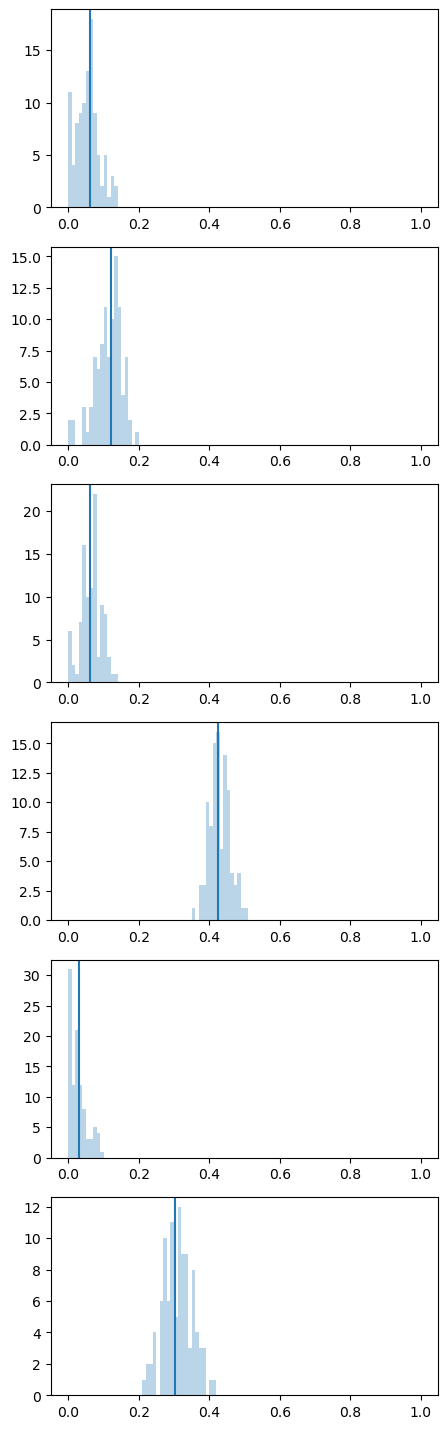

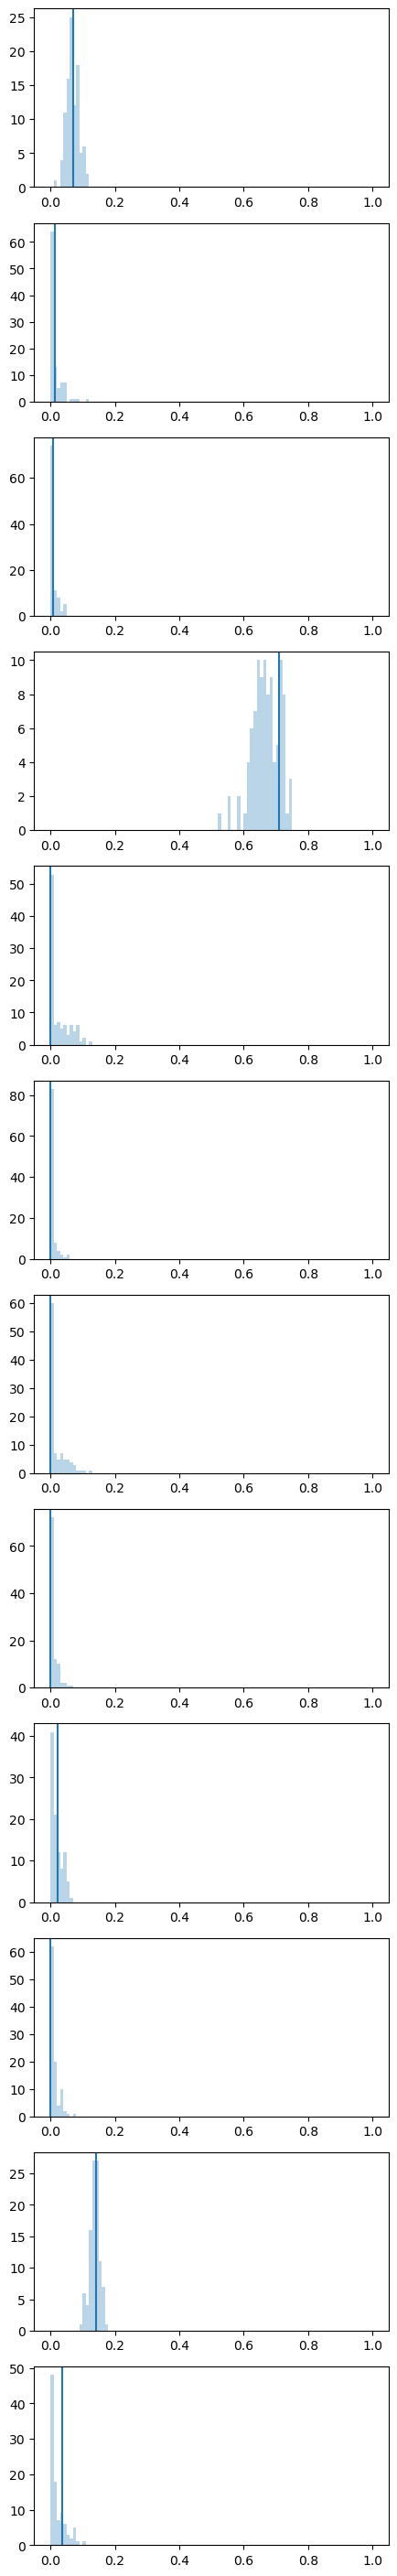

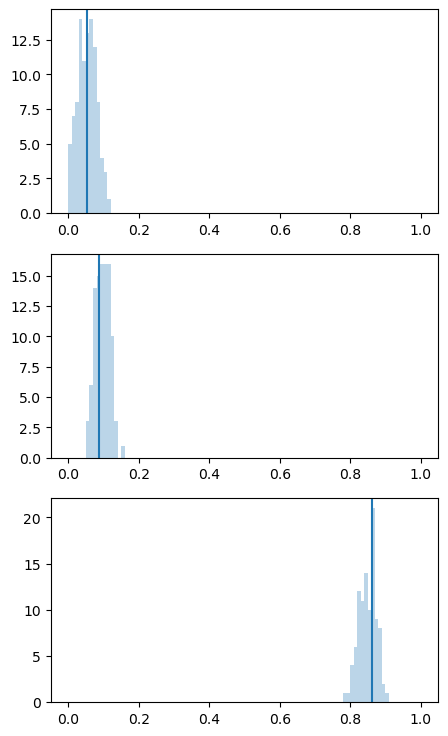

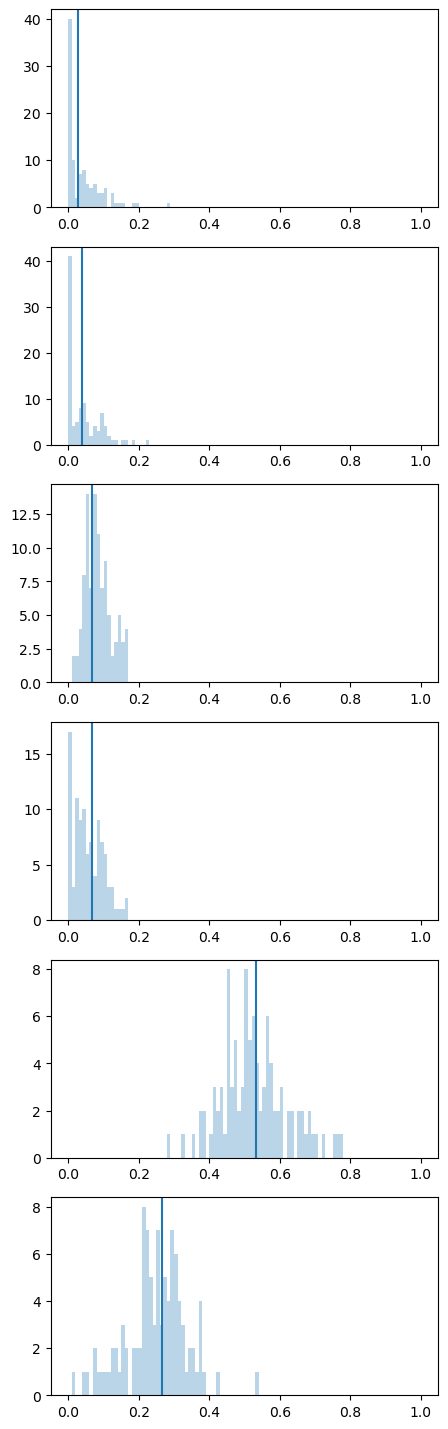

In [100]:

for loc in loci:
    if truth_available:
        sum_true_activities = sum(true_activities[loc.id].values())
    fig, axs = plt.subplots(len(loc.rgr_set), 1, figsize=(5, 3*len(loc.rgr_set)))
    for i, rgr in enumerate(loc.rgr_set):
        axs[i].hist(loc.norm_result[rgr.index,:], bins=100, alpha=.3, range=(0,1))
        if truth_available:
            try:
                axs[i].axvline(true_activities[loc.id][rgr]/sum_true_activities)
            except KeyError:
                axs[i].axvline(0)